In [2]:
import sys
import os
from pathlib import Path

# Add project root to path to import from src
project_root = Path("/home/tarakesh/Work/Repo/measurement-free-quantum-classifier")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
from src.data.pcam_loader import get_pcam_dataset

In [4]:
# Load the dataset
dataset = get_pcam_dataset(split='val', download=False)
print(f"Dataset loaded with {len(dataset)} samples.")

Dataset loaded with 32768 samples.


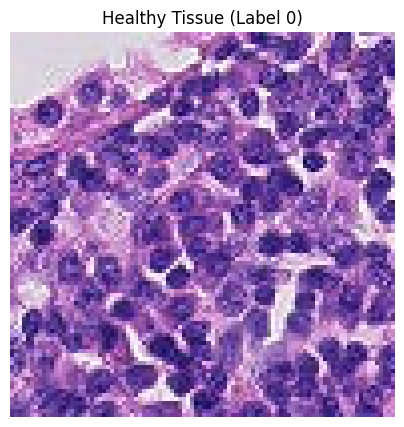

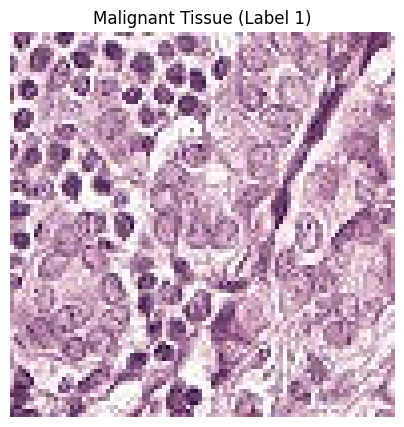

In [7]:
# Find one healthy (0) and one malignant (1) sample
healthy_idx = None
malignant_idx = None

for i in range(len(dataset)):
    _, label = dataset[i]
    if label == 0 and healthy_idx is None:
        healthy_idx = i
    if label == 1 and malignant_idx is None:
        malignant_idx = i
    if healthy_idx is not None and malignant_idx is not None:
        break

healthy_img, _ = dataset[healthy_idx]
malignant_img, _ = dataset[malignant_idx]

# Convert to numpy and transpose from CHW to HWC for plotting
healthy_img = healthy_img.permute(1, 2, 0).numpy()
malignant_img = malignant_img.permute(1, 2, 0).numpy()

# Display Healthy Tissue separately
plt.figure(figsize=(5, 5))
plt.imshow(healthy_img)
plt.title("Healthy Tissue (Label 0)")
plt.axis('off')
plt.show()

# Display Malignant Tissue separately
plt.figure(figsize=(5, 5))
plt.imshow(malignant_img)
plt.title("Malignant Tissue (Label 1)")
plt.axis('off')
plt.show()